# Machine Learning Based Network Intrusion Detection System


## Objective
The goal of this project is to build a machine learning based intrusion detection system capable of classifying network traffic as either normal or malicious.

## Algorithms Used
- Logistic Regression
- Random Forest
- XGBoost

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC Curve

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

Load Dataset

In [3]:
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
"hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
"num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
"is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
"same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

data = pd.read_csv(url,names=columns)

data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Data Preprocessing

In [4]:
data['label'] = data['label'].apply(lambda x: 0 if x == 'normal' else 1)

Encode Categorical Features

In [5]:
categorical_cols = ['protocol_type','service','flag']

encoder = LabelEncoder()

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

Split Features and Target

In [6]:
X = data.drop(['label','difficulty'],axis=1)
y = data['label']

Train Test Split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Train Machine Learning Models

In [8]:
log_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

log_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)
xgb_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:47:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Predictions

In [9]:
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

Evaluation Metrics Table

In [10]:
results = pd.DataFrame({
"Model":["Logistic Regression","Random Forest","XGBoost"],

"Accuracy":[
accuracy_score(y_test,log_pred),
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,xgb_pred)
],

"Precision":[
precision_score(y_test,log_pred),
precision_score(y_test,rf_pred),
precision_score(y_test,xgb_pred)
],

"Recall":[
recall_score(y_test,log_pred),
recall_score(y_test,rf_pred),
recall_score(y_test,xgb_pred)
],

"F1 Score":[
f1_score(y_test,log_pred),
f1_score(y_test,rf_pred),
f1_score(y_test,xgb_pred)
]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.886724,0.928922,0.820352,0.871267
1,Random Forest,0.998611,0.999404,0.997622,0.998512
2,XGBoost,0.999206,0.999066,0.999236,0.999151


Model Accuracy Comparison Graph

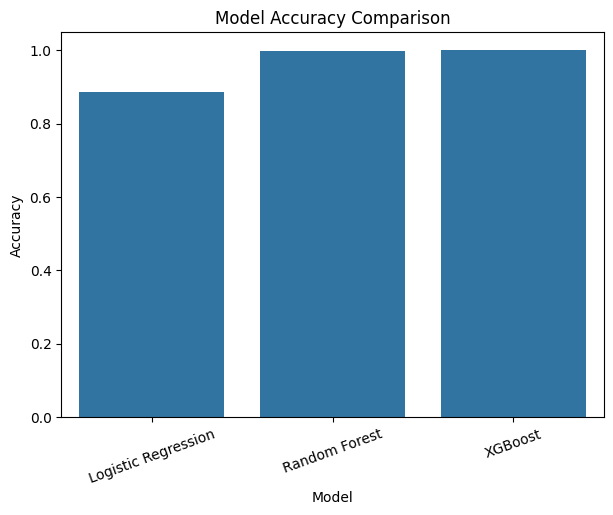

In [11]:
plt.figure(figsize=(7,5))

sns.barplot(x="Model",y="Accuracy",data=results)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

Confusion Matrix (Random Forest)

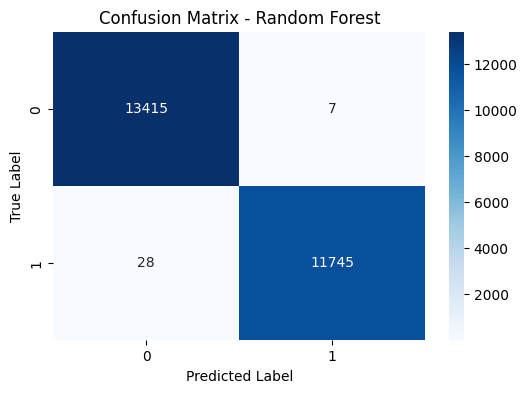

In [12]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

ROC Curve Comparison

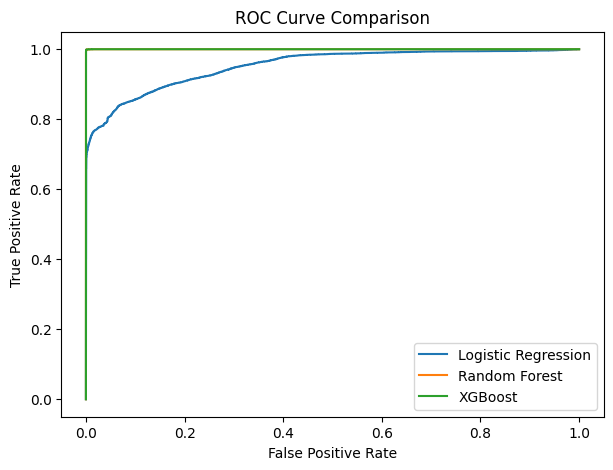

In [13]:
log_probs = log_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

fpr1,tpr1,_ = roc_curve(y_test,log_probs)
fpr2,tpr2,_ = roc_curve(y_test,rf_probs)
fpr3,tpr3,_ = roc_curve(y_test,xgb_probs)

plt.figure(figsize=(7,5))

plt.plot(fpr1,tpr1,label="Logistic Regression")
plt.plot(fpr2,tpr2,label="Random Forest")
plt.plot(fpr3,tpr3,label="XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

ROC AUC Scores

In [14]:
roc_scores = {
"Logistic Regression":roc_auc_score(y_test,log_probs),
"Random Forest":roc_auc_score(y_test,rf_probs),
"XGBoost":roc_auc_score(y_test,xgb_probs)
}

roc_scores

{'Logistic Regression': np.float64(0.9527029100868927),
 'Random Forest': np.float64(0.9999911876685125),
 'XGBoost': np.float64(0.9999943677019576)}

Feature Importance

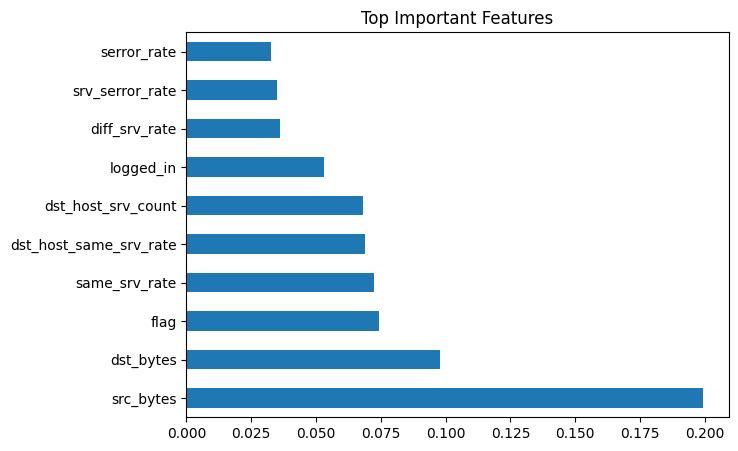

In [15]:
importance = rf_model.feature_importances_

feature_importance = pd.Series(
importance,
index=X.columns
)

feature_importance.nlargest(10).plot(
kind='barh',
figsize=(7,5)
)

plt.title("Top Important Features")

plt.show()

## Example Prediction

In [17]:
sample = X_test.iloc[0].values.reshape(1,-1)

prediction = rf_model.predict(sample)

if prediction[0] == 0:
    print("Network Traffic Prediction: Normal")
else:
    print("Network Traffic Prediction: Malicious")

Network Traffic Prediction: Normal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [18]:
actual = y_test.iloc[0]

print("Actual Label:", "Normal" if actual==0 else "Malicious")
print("Predicted Label:", "Normal" if prediction[0]==0 else "Malicious")

Actual Label: Normal
Predicted Label: Normal


## Discussion

The experimental results show that ensemble models such as Random Forest and XGBoost outperform Logistic Regression in detecting network intrusions.

The ROC curve comparison demonstrates that ensemble methods provide stronger classification performance and better ability to distinguish between normal and malicious traffic.

## Conclusion

This project implemented a machine learning based intrusion detection system using the NSL-KDD dataset.

Three models were evaluated: Logistic Regression, Random Forest, and XGBoost.

The results indicate that ensemble learning models such as Random Forest and XGBoost achieve higher detection accuracy and better classification performance compared to simple linear models.

Machine learning based intrusion detection systems can significantly enhance network security by automatically identifying malicious activities.